In [1]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 3.8 MB/s eta 0:00:00


In [2]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [3]:
# Variables de entrada
temperatura = ctrl.Antecedent(np.arange(35, 42.1, 0.1), 'temperatura')
presion = ctrl.Antecedent(np.arange(80, 201, 1), 'presion')
dolor = ctrl.Antecedent(np.arange(0, 11, 1), 'dolor')

# Variable de salida
prioridad = ctrl.Consequent(np.arange(0, 101, 1), 'prioridad')

print("Variables creadas correctamente")

Variables creadas correctamente


In [4]:
# FUNCIONES DE PERTENENCIA


# Temperatura
temperatura['normal'] = fuzz.trapmf(
    temperatura.universe,
    [35, 35, 36.5, 37.4]
)

temperatura['moderada'] = fuzz.trimf(
    temperatura.universe,
    [36.8, 38.0, 39.0]
)

temperatura['alta'] = fuzz.trapmf(
    temperatura.universe,
    [38.0, 39.5, 42, 42]
)


# Presión Sistólica
presion['baja'] = fuzz.trapmf(
    presion.universe,
    [80, 80, 90, 105]
)

presion['normal'] = fuzz.trimf(
    presion.universe,
    [95, 120, 140]
)

presion['alta'] = fuzz.trapmf(
    presion.universe,
    [130, 150, 200, 200]
)


# Nivel de Dolor
dolor['leve'] = fuzz.trapmf(
    dolor.universe,
    [0, 0, 2, 4]
)

dolor['moderado'] = fuzz.trimf(
    dolor.universe,
    [3, 5, 7]
)

dolor['intenso'] = fuzz.trapmf(
    dolor.universe,
    [6, 8, 10, 10]
)


# Prioridad de Atención
prioridad['baja'] = fuzz.trapmf(
    prioridad.universe,
    [0, 0, 20, 35]
)

prioridad['media'] = fuzz.trimf(
    prioridad.universe,
    [25, 45, 60]
)

prioridad['alta'] = fuzz.trimf(
    prioridad.universe,
    [50, 70, 85]
)

prioridad['critica'] = fuzz.trapmf(
    prioridad.universe,
    [75, 90, 100, 100]
)

print("Funciones de pertenencia creadas correctamente")

Funciones de pertenencia creadas correctamente


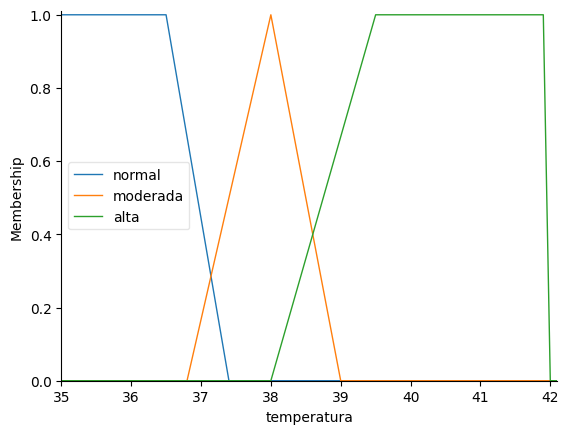

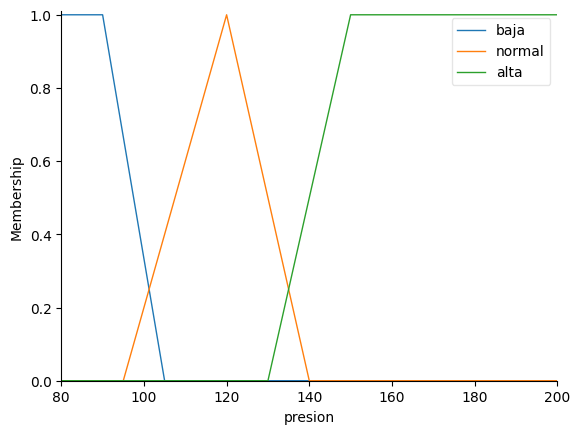

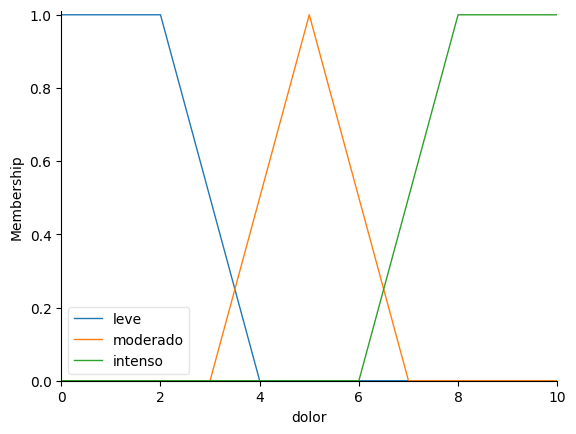

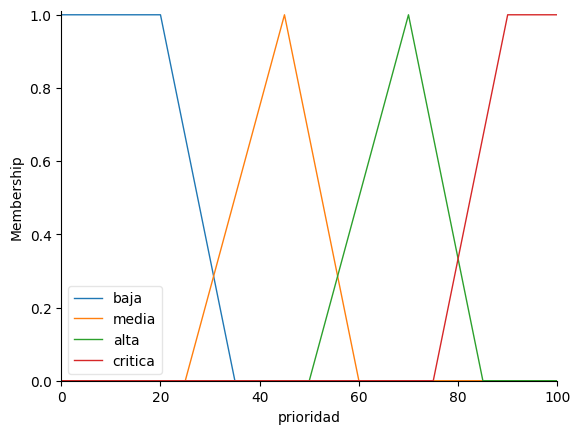

In [5]:
# Visualizar las funciones de pertenencia

temperatura.view()
presion.view()
dolor.view()
prioridad.view()

plt.show()

In [6]:
# REGLAS DIFUSAS

#Prioridad Baja
regla1 = ctrl.Rule(
    temperatura['normal'] & presion['normal'] & dolor['leve'],
    prioridad['baja']
)

#Prioridad Media
regla2 = ctrl.Rule(
    temperatura['normal'] & presion['normal'] & dolor['moderado'],
    prioridad['media']
)

regla3 = ctrl.Rule(
    temperatura['moderada'] & presion['normal'],
    prioridad['media']
)

#Prioridad Alta
regla4 = ctrl.Rule(
    temperatura['moderada'] & presion['alta'],
    prioridad['alta']
)

regla5 = ctrl.Rule(
    temperatura['alta'],
    prioridad['alta']
)

regla6 = ctrl.Rule(
    presion['alta'],
    prioridad['alta']
)

regla7 = ctrl.Rule(
    presion['baja'],
    prioridad['alta']
)

regla8 = ctrl.Rule(
    dolor['intenso'],
    prioridad['alta']
)

#Prioridad Critica
regla9 = ctrl.Rule(
    temperatura['alta'] & dolor['intenso'],
    prioridad['critica']
)

regla10 = ctrl.Rule(
    presion['baja'] & dolor['intenso'],
    prioridad['critica']
)

regla11 = ctrl.Rule(
    presion['alta'] & dolor['intenso'],
    prioridad['critica']
)

regla12 = ctrl.Rule(
    temperatura['alta'] & presion['alta'],
    prioridad['critica']
)

print("Reglas difusas creadas correctamente")

Reglas difusas creadas correctamente


In [7]:
# MOTOR DE INFERENCIA DIFUSA


sistema_control = ctrl.ControlSystem([
    regla1, regla2, regla3, regla4, regla5, regla6, regla7, regla8, regla9, regla10, regla11, regla12
])

sistema_triaje = ctrl.ControlSystemSimulation(sistema_control)

print("Motor de inferencia creado correctamente")

Motor de inferencia creado correctamente


In [21]:
# PRUEBA


sistema_triaje.input['temperatura'] = 39
sistema_triaje.input['presion'] = 150
sistema_triaje.input['dolor'] = 9

# Ejecutar el sistema
sistema_triaje.compute()

# Obtener resultado
resultado = sistema_triaje.output['prioridad']

print("Prioridad calculada:", round(resultado, 2))

Prioridad calculada: 79.5


In [20]:
# PRUEBA COMPLETA


# Datos del paciente
temp_paciente = 39
presion_paciente = 150
dolor_paciente = 9

# Crear una nueva simulación
prueba = ctrl.ControlSystemSimulation(sistema_control)

# Ingresar datos
prueba.input['temperatura'] = temp_paciente
prueba.input['presion'] = presion_paciente
prueba.input['dolor'] = dolor_paciente

# Ejecutar lógica difusa
prueba.compute()

# Obtener prioridad
resultado = prueba.output['prioridad']

# Clasificar resultado
if resultado < 35:
    clasificacion = "BAJA"

elif resultado < 60:
    clasificacion = "MEDIA"

elif resultado < 80:
    clasificacion = "ALTA"

else:
    clasificacion = "CRÍTICA"

# Mostrar resultado
print("==============================")
print("RESULTADO")
print("==============================")

print("Temperatura:", temp_paciente, "°C")
print("Presión sistólica:", presion_paciente, "mmHg")
print("Dolor:", str(dolor_paciente) + "/10")

print("------------------------------")

print("Prioridad:", round(resultado, 2), "/ 100")
print("Clasificación:", clasificacion)

print("==============================")

RESULTADO
Temperatura: 39 °C
Presión sistólica: 150 mmHg
Dolor: 9/10
------------------------------
Prioridad: 79.5 / 100
Clasificación: ALTA


In [22]:
#CREAR LA FUNCIÓN PARA EVALUAR


def evaluar_paciente(temperatura_valor, presion_valor, dolor_valor):

    # Validar rangos permitidos
    if temperatura_valor < 35 or temperatura_valor > 42:
        raise ValueError("La temperatura debe estar entre 35 y 42 °C.")

    if presion_valor < 80 or presion_valor > 200:
        raise ValueError("La presión debe estar entre 80 y 200 mmHg.")

    if dolor_valor < 0 or dolor_valor > 10:
        raise ValueError("El dolor debe estar entre 0 y 10.")

    # Crear una simulación nueva
    simulacion = ctrl.ControlSystemSimulation(sistema_control)

    # Asignar datos
    simulacion.input['temperatura'] = temperatura_valor
    simulacion.input['presion'] = presion_valor
    simulacion.input['dolor'] = dolor_valor

    # Ejecutar el sistema
    simulacion.compute()

    # Obtener resultado
    resultado = simulacion.output['prioridad']

    # Clasificación
    if resultado < 35:
        clasificacion = "BAJA"
    elif resultado < 60:
        clasificacion = "MEDIA"
    elif resultado < 80:
        clasificacion = "ALTA"
    else:
        clasificacion = "CRÍTICA"

    return resultado, clasificacion

In [25]:
#PRUEBA DE LA FUNCIÓN

resultado, clasificacion = evaluar_paciente(
    39,
    150,
    9
)

print("Prioridad:", round(resultado, 2))
print("Clasificación:", clasificacion)

Prioridad: 79.5
Clasificación: ALTA


In [27]:
#INTERFAZ


print("====================================")
print(" SISTEMA DIFUSO DE PRIORIZACIÓN")
print("====================================")

try:
    temp = float(input("Temperatura del paciente (35-42 °C): "))
    pres = float(input("Presión sistólica (80-200 mmHg): "))
    dol = float(input("Nivel de dolor (0-10): "))

    resultado, clasificacion = evaluar_paciente(
        temp,
        pres,
        dol
    )

    print("\n====================================")
    print(" RESULTADO")
    print("====================================")

    print("Temperatura:", temp, "°C")
    print("Presión sistólica:", pres, "mmHg")
    print("Dolor:", str(dol) + "/10")

    print("------------------------------------")

    print("Prioridad:", round(resultado, 2), "/ 100")
    print("Clasificación:", clasificacion)

    print("====================================")

except ValueError as error:
    print("\nERROR:", error)

 SISTEMA DIFUSO DE PRIORIZACIÓN
Temperatura del paciente (35-42 °C): 39
Presión sistólica (80-200 mmHg): 150
Nivel de dolor (0-10): 9

 RESULTADO
Temperatura: 39.0 °C
Presión sistólica: 150.0 mmHg
Dolor: 9.0/10
------------------------------------
Prioridad: 79.5 / 100
Clasificación: ALTA


In [30]:
import pandas as pd

In [32]:
#CREACIÓN DE DATOS DE PRUEBA


datos_prueba = {
    'paciente': [
        'Paciente 1', 'Paciente 2', 'Paciente 3', 'Paciente 4', 'Paciente 5'
    ],

    'temperatura': [
        36.5, 37.8, 38.6, 39.2, 36.9
    ],

    'presion': [
        120, 135, 145, 160, 95
    ],

    'dolor': [
        2, 5, 7, 9, 8
    ]
}

df_pacientes = pd.DataFrame(datos_prueba)

df_pacientes

,paciente,temperatura,presion,dolor
0,Paciente 1,36.5,120,2
1,Paciente 2,37.8,135,5
2,Paciente 3,38.6,145,7
3,Paciente 4,39.2,160,9
4,Paciente 5,36.9,95,8


In [33]:
#GUARDADO DE CSV


df_pacientes.to_csv(
    'pacientes_prueba.csv',
    index=False
)

print("Archivo pacientes_prueba.csv creado correctamente")

Archivo pacientes_prueba.csv creado correctamente


In [34]:
# EVALUAR DATOS DE PRUEBA


resultados = []

for _, paciente in df_pacientes.iterrows():

    prioridad_calculada, clasificacion = evaluar_paciente(
        paciente['temperatura'],
        paciente['presion'],
        paciente['dolor']
    )

    resultados.append({
        'paciente': paciente['paciente'],
        'temperatura': paciente['temperatura'],
        'presion': paciente['presion'],
        'dolor': paciente['dolor'],
        'prioridad': round(prioridad_calculada, 2),
        'clasificacion': clasificacion
    })


df_resultados = pd.DataFrame(resultados)

df_resultados

,paciente,temperatura,presion,dolor,prioridad,clasificacion
0,Paciente 1,36.5,120,2,14.09,BAJA
1,Paciente 2,37.8,135,5,55.30,MEDIA
2,Paciente 3,38.6,145,7,76.28,ALTA
3,Paciente 4,39.2,160,9,79.50,ALTA
4,Paciente 5,36.9,95,8,77.48,ALTA


In [35]:
#GUARDADO DE PRUEBAS


df_resultados.to_csv(
    'resultados_prueba.csv',
    index=False
)

print("Resultados guardados correctamente")

Resultados guardados correctamente


In [37]:
import sys
import numpy
import pandas
import matplotlib
import skfuzzy

print("Python:", sys.version.split()[0])
print("NumPy:", numpy.__version__)
print("Pandas:", pandas.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Scikit-Fuzzy:", skfuzzy.__version__)

Python: 3.13.15
NumPy: 2.1.3
Pandas: 2.2.3
Matplotlib: 3.10.0
Scikit-Fuzzy: 0.5.0


In [38]:
%%writefile requirements.txt
Python: 3.13.15
NumPy: 2.1.3
Pandas: 2.2.3
Matplotlib: 3.10.0
Scikit-Fuzzy: 0.5.0

Overwriting requirements.txt
